In [1]:
import cv2

In [3]:
import os

In [5]:
import numpy as np

In [7]:
from tensorflow.keras.models import Sequential

In [9]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense

In [11]:
from tensorflow.keras.utils import to_categorical

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
import matplotlib.pyplot as plt

In [16]:
dataset_path=('C:\\Users\\HP\\Documents\\Hand Gesture Dataset')
class_labels=['class 1','class 2','class 3']

In [19]:
images=[]
labels=[]

In [21]:
for i,class_label in enumerate(class_labels):
    class_path=os.path.join(dataset_path,class_label)
    for file in os.listdir(class_path):
        if file.endswith('.jpg')or file.endswith('.png'):
            img_path=os.path.join(class_path,file)
            img=cv2.imread(img_path)
            img=cv2.resize(img,(224,224))
            images.append(img)
            labels.append(i)
                          
                                                 
    
    

In [23]:
images=np.array(images)
labels=to_categorical(labels)

In [25]:
train_images,test_images,train_labels,test_labels=train_test_split(images,labels,test_size=0.2,random_state=42)

In [27]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(len(class_labels),activation='softmax'))
          

In [29]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [31]:
model.fit(train_images,train_labels,epochs=10,batch_size=32,validation_data=(test_images,test_labels))
          

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.3421 - loss: 1311.1025 - val_accuracy: 0.6000 - val_loss: 802.5923
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5071 - loss: 571.7333 - val_accuracy: 0.6000 - val_loss: 299.9396
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5073 - loss: 195.0382 - val_accuracy: 0.6333 - val_loss: 89.6092
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6033 - loss: 43.6737 - val_accuracy: 0.7667 - val_loss: 8.3594
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.7067 - loss: 12.7956 - val_accuracy: 0.5000 - val_loss: 3.1156
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6802 - loss: 1.4982 - val_accuracy: 0.9000 - val_loss: 0.6103
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.8779 - loss: 0.3086 - val_accuracy: 0.8667 - val_loss: 0.7944
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9585 - loss: 0.1810 - val_accuracy: 0.9333 - val_loss: 0.5970
E

In [33]:
input_image=cv2.imread('input_image_path.jpg')

In [37]:
input_image=cv2.resize(img,(224,224))
input_image=np.expand_dims(input_image,axis=0)

In [43]:
prediction=model.predict(input_image)
predicted_class=class_labels[np.argmax(prediction)]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


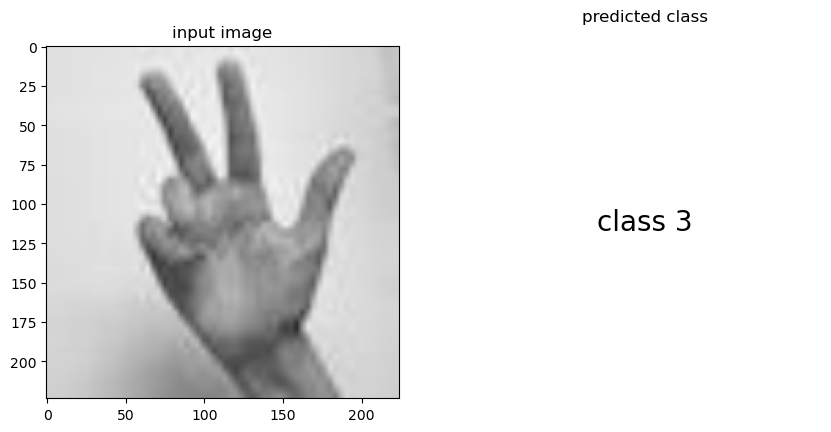

In [57]:
fig,axes=plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(cv2.cvtColor(input_image[0],cv2.COLOR_BGR2RGB))
axes[0].set_title('input image')
axes[1].text(0.5,0.5,predicted_class,ha='center',va='center',size=20)
axes[1].set_title('predicted class')
axes[1].axis('off')
plt.show()